#Project Title
##🛍️ Customer Segmentation System using K-Means Clustering

#Problem Statement

Businesses often have thousands of customers with different purchasing behaviors. Without grouping these customers, it becomes difficult to create personalized marketing campaigns, improve customer satisfaction, or increase sales.

The challenge is to identify customers with similar characteristics so that businesses can target them more effectively.

#Objective

The objective of this project is to use the K-Means Clustering algorithm to segment customers into meaningful groups based on their characteristics.

The project aims to:

* Understand customer behavior.
* Identify similar customer groups.
* Determine the optimal number of clusters using the Elbow Method.
* Visualize customer segments.
* Generate business insights for decision-making.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


#Dataset

We will use the Mall Customers Dataset.

Features


| Feature                | Description                            |
| ---------------------- | -------------------------------------- |
| CustomerID             | Unique customer ID                     |
| Gender                 | Male/Female                            |
| Age                    | Customer Age                           |
| Annual Income (k$)     | Annual income in thousand dollars      |
| Spending Score (1-100) | Spending behavior assigned by the mall |


#Expected Outcome

After completing this project, we will be able to identify clusters such as:

* 💎 Premium Customers
* 🛍️ High Spenders
* 💰 Budget Customers
* 👨‍👩‍👧 Family Customers
* 🎯 Potential Customers

These insights can help businesses design personalized marketing strategies.

In [21]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
df.shape

(200, 5)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


In [25]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [26]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset through statistical summaries and visualizations.

Before applying K-Means clustering, we analyze the distribution of features, relationships between variables, and identify any unusual patterns or outliers.

In [29]:
df.dtypes

,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [30]:
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


In [31]:
df.drop('CustomerID', axis=1, inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


##Distribution of numerical features

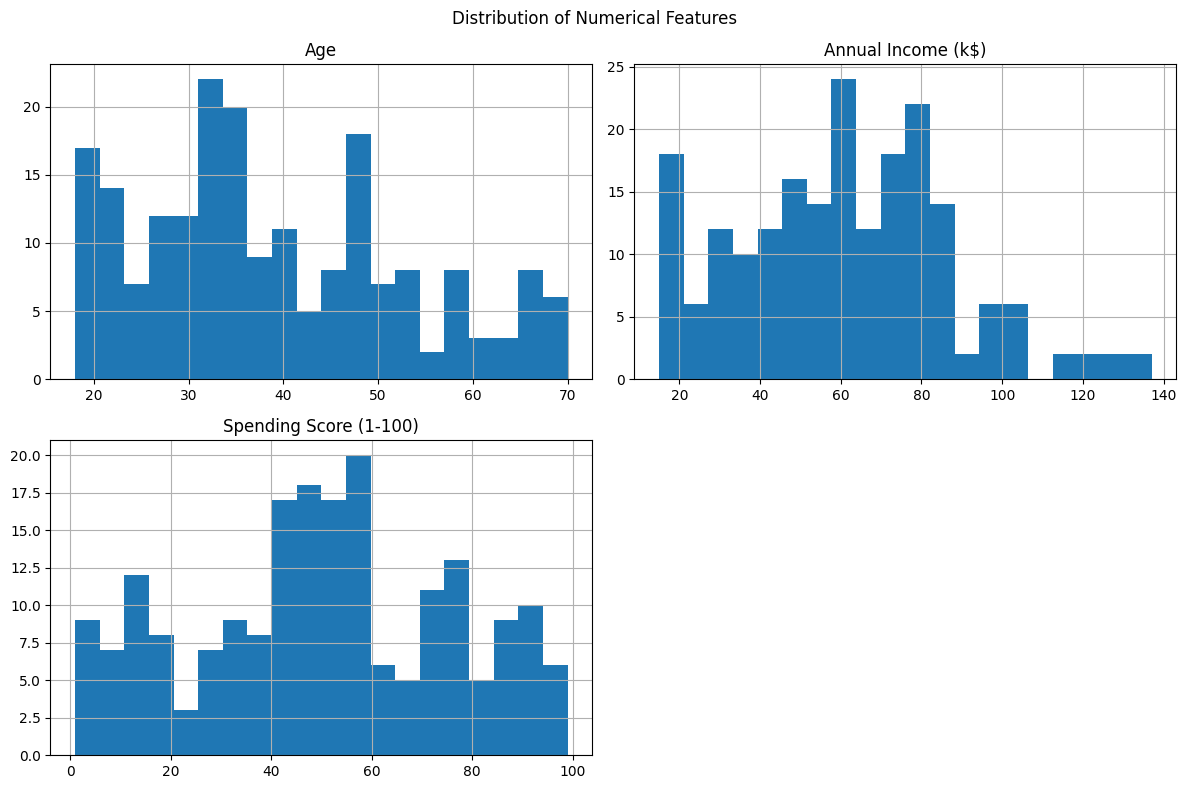

In [32]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

##2. Gender Distribution

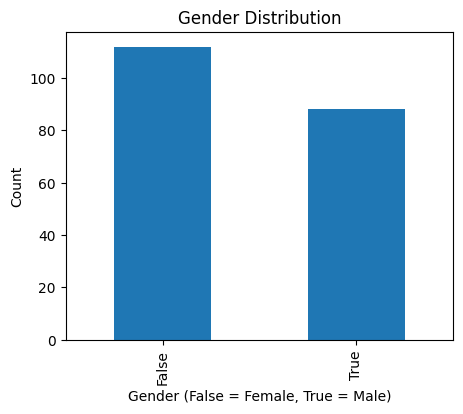

In [33]:
df['Genre_Male'].value_counts().plot(
    kind='bar',
    figsize=(5,4),
    title='Gender Distribution'
)

plt.xlabel('Gender (False = Female, True = Male)')
plt.ylabel('Count')
plt.show()

##Correalation matrix

In [34]:
corr = df.corr(numeric_only=True)
corr

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
Age,1.000000,-0.012398,-0.327227,0.060867
Annual Income (k$),-0.012398,1.000000,0.009903,0.056410
Spending Score (1-100),-0.327227,0.009903,1.000000,-0.058109
Genre_Male,0.060867,0.056410,-0.058109,1.000000


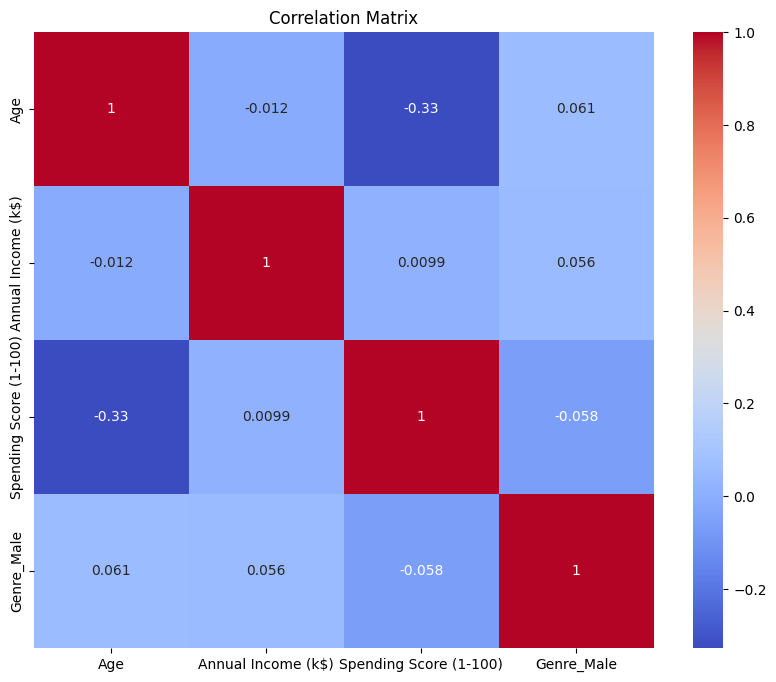

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Scatter Plot

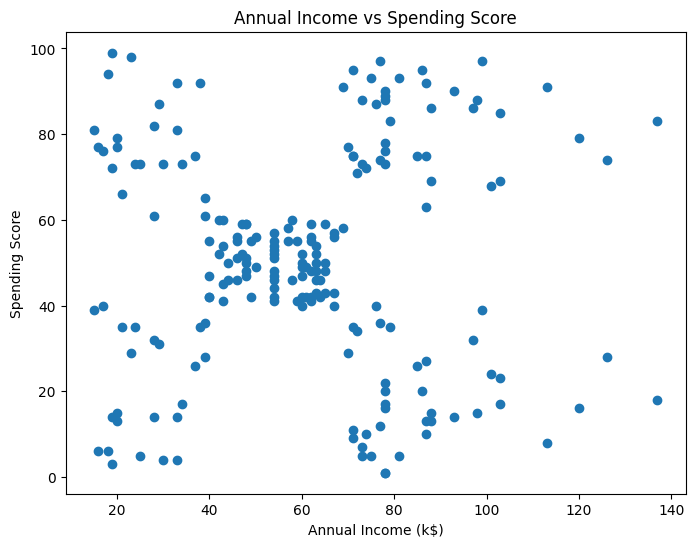

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Annual Income vs Spending Score")

plt.show()

##EDA Summary

1. The dataset contains no missing values.

2. Gender was successfully converted into a numerical feature using One-Hot Encoding.

3. Age, Annual Income, and Spending Score show different value ranges, indicating that feature scaling is necessary before applying K-Means.

4. The scatter plot of Annual Income vs. Spending Score suggests the presence of natural customer groupings, making K-Means a suitable clustering algorithm.

5. Boxplots should be reviewed for potential outliers, as K-Means is distance-based and sensitive to extreme values.

#Check for Outliers

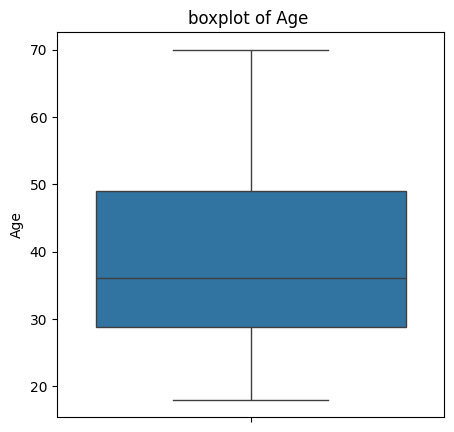

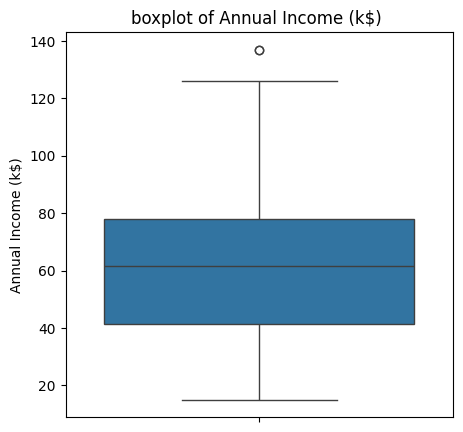

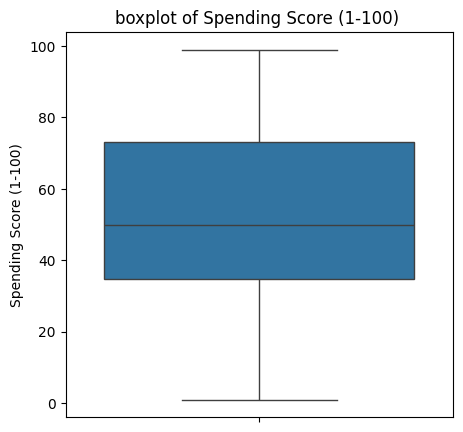

In [42]:
columns =['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in columns:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(f"boxplot of {col} ")
  plt.show()

In [43]:
# Find customers with Annual Income greater than 130k$

df[df['Annual Income (k$)'] > 130]

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
198,32,137,18,True
199,30,137,83,True


##Outlier Analysis

Boxplots were used to identify potential outliers in the numerical features. A small number of outliers were observed in the Annual Income feature. Since these values are plausible customer records and not data entry errors, they were retained. In customer segmentation, high-income customers can represent an important business segment, so removing them could reduce the usefulness of the clustering results.

#Step 4: Feature Scaling
If one feature has much larger values than another, it will dominate the distance calculation. Standardizing the features ensures each contributes fairly.

In [45]:
ss = StandardScaler()
df_scaled = ss.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=(df.columns))
df_scaled

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


In [47]:
df_scaled.describe().round(2)

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
count,200.00,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.50,-1.74,-1.91,-0.89
25%,-0.72,-0.73,-0.60,-0.89
50%,-0.20,0.04,-0.01,-0.89
75%,0.73,0.67,0.89,1.13
max,2.24,2.92,1.89,1.13


#Step 5: Find the Optimal Number of Clusters (Elbow Method)

In [54]:
cluster = []
for i in range(1, 11):
  kmeans= KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
  kmeans.fit(df_scaled)
  cluster.append(kmeans.inertia_)



In [55]:
cluster

[800.0000000000003,
 588.8026767824932,
 476.78755441351575,
 388.7178614053844,
 331.3098837641085,
 276.4117595313096,
 236.20494707086885,
 199.75046112065573,
 174.23547730691482,
 152.02983429775693]

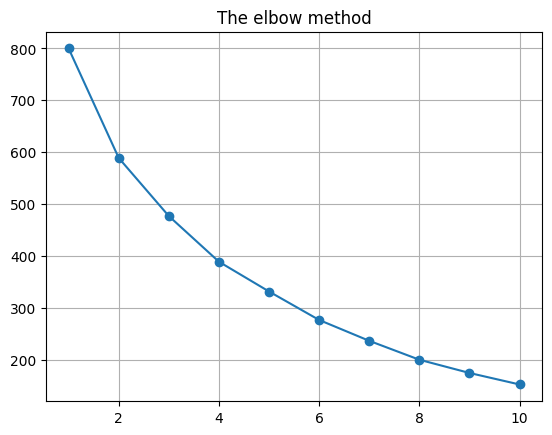

In [60]:
from matplotlib import markers
plt.plot(range(1,11), cluster, marker='o')
plt.xlabel
plt.title('The elbow method')
plt.grid(True)
plt.show()

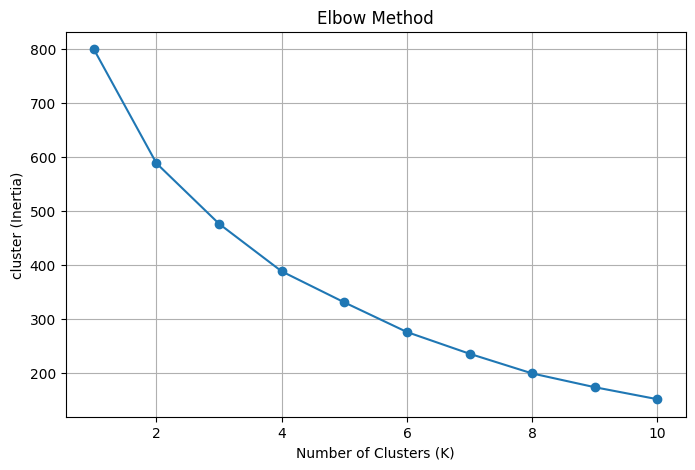

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), cluster, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("cluster (Inertia)")

plt.grid(True)
plt.show()

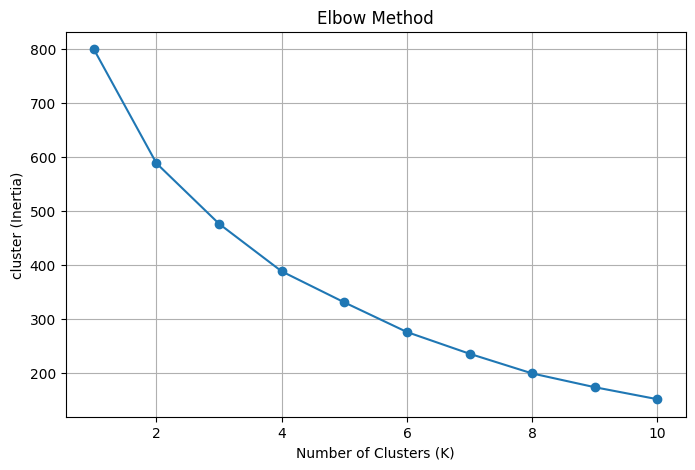

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), cluster, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("cluster (Inertia)")

plt.grid(True)
plt.show()

In [61]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(df_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [62]:
y = kmeans_model.predict(df_scaled)

In [63]:
df['cluster'] = y
df

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,cluster
0,19,15,39,True,3
1,21,15,81,True,3
2,20,16,6,False,3
3,23,16,77,False,3
4,31,17,40,False,3
...,...,...,...,...,...
195,35,120,79,False,0
196,45,126,28,False,1
197,32,126,74,True,0
198,32,137,18,True,1


In [65]:
df['cluster'].value_counts()

,count
cluster,
3,54
2,43
0,39
4,35
1,29


In [66]:
# Analyze each cluster

cluster_summary = df.groupby('cluster').mean(numeric_only=True)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
cluster,,,,
0,32.692308,86.538462,82.128205,0.461538
1,36.482759,89.517241,18.000000,0.448276
2,49.813953,49.232558,40.069767,0.000000
3,24.907407,39.722222,61.203704,0.407407
4,55.714286,53.685714,36.771429,1.000000


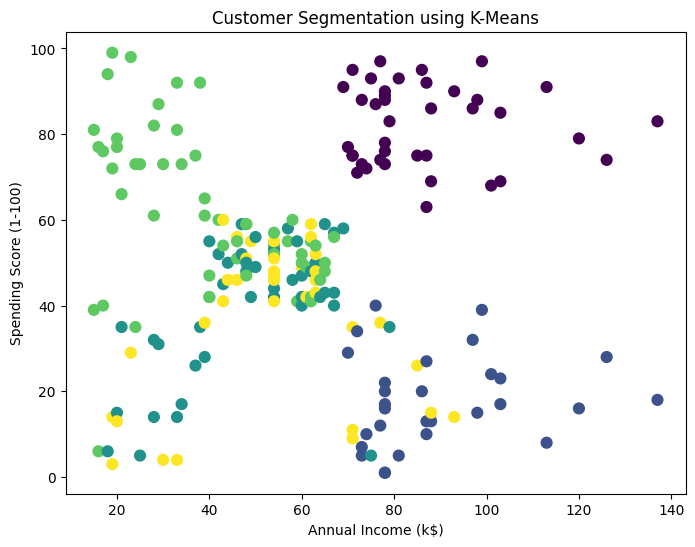

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')

plt.show()

| Cluster | Avg Age | Avg Income | Avg Spending | Business Label                            | Interpretation                                                                                                                     |
| ------: | ------: | ---------: | -----------: | ----------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
|   **0** |   32.69 |  **86.54** |    **82.13** | 💎 **Premium Customers**                  | High income and high spending. These are the most valuable customers and should receive VIP offers and loyalty rewards.            |
|   **1** |   36.48 |  **89.52** |    **18.00** | 💼 **High-Income Conservative Customers** | High income but low spending. They have purchasing power but spend cautiously. Target them with personalized premium offers.       |
|   **2** |   49.81 |      49.23 |        40.07 | 👨‍💼 **Average Customers**               | Moderate income and moderate spending. Regular marketing campaigns can encourage higher engagement.                                |
|   **3** |   24.91 |  **39.72** |    **61.20** | 🛍️ **Young High Spenders**               | Young customers with relatively lower income but high spending. They are likely attracted to trends, promotions, and new products. |
|   **4** |   55.71 |      53.69 |        36.77 | 💰 **Budget Customers**                   | Older customers with moderate income and lower spending. Discounts and value-for-money offers may appeal to this group.            |


## Business Insights

The K-Means clustering algorithm successfully segmented customers into five distinct groups based on their age, annual income, spending score, and gender.

### Cluster 0 – Premium Customers 💎
- High annual income
- High spending score
- Most valuable customers
- Suitable for loyalty programs, exclusive memberships, and premium product promotions.

### Cluster 1 – High-Income Conservative Customers 💼
- High annual income
- Low spending score
- Customers with strong purchasing power but conservative spending habits.
- Personalized premium offers and targeted marketing may increase engagement.

### Cluster 2 – Average Customers 👨‍💼
- Moderate income
- Moderate spending
- Represent the largest middle customer segment.
- Regular marketing campaigns can improve customer retention.

### Cluster 3 – Young High Spenders 🛍️
- Youngest customer group
- Lower income but high spending behavior
- Likely to respond well to fashion trends, seasonal promotions, and social media campaigns.

### Cluster 4 – Budget Customers 💰
- Older customers
- Moderate income
- Lower spending score
- Discounts, bundled offers, and value-oriented products may increase purchases.